In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/

'app hs.gdoc'			      multiple_regression.ipynb
'Colab Notebooks'		     'my pdf.pdf'
'cover letter (1).gdoc'		      Nsus.gdoc
'cover letter (2).gdoc'		      Song.gdoc
'cover letter.gdoc'		      superstore_sales.csv
 dataset			     'Untitled document (1).gdoc'
 datasets			     'Untitled document (2).gdoc'
 eBay.pdf			     'Untitled document (3).gdoc'
 HW6a.gdoc			     'Untitled document.gdoc'
'InApp - Interview Questions..docx'


In [4]:
file_path = "/content/drive/MyDrive/superstore_sales.csv"

In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/superstore_sales.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.shape
df.columns
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

np.int64(0)

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [8]:
# Create Year Feature
df['Year'] = df['Order Date'].dt.year

# Create Month Feature
df['Month'] = df['Order Date'].dt.month

# Create Month Name
df['Month_Name'] = df['Order Date'].dt.month_name()

# Create Quarter Feature
df['Quarter'] = df['Order Date'].dt.quarter

# Create Day of Week Feature
df['Day_of_Week'] = df['Order Date'].dt.day_name()

# Preview Updated Dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Quarter,Day_of_Week
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,Tuesday


In [9]:
# Standard column mapping
column_mapping = {
    'Order Date': 'order_date',
    'Ship Date': 'ship_date',
    'Customer ID': 'customer_id',
    'Customer Name': 'customer_name',
    'Segment': 'segment',
    'City': 'city',
    'State': 'state',
    'Region': 'region',
    'Category': 'category',
    'Sub-Category': 'sub_category',
    'Product Name': 'product_name',
    'Sales': 'sales'
}

# Rename columns
df = df.rename(columns=column_mapping)

# Required columns
required_columns = ['order_date', 'customer_name', 'region', 'category', 'product_name', 'sales']

# Check missing required columns
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing required columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


In [10]:
# ================================
# STANDARD SCHEMA MAPPING
# ================================

column_mapping = {
    'Row ID': 'row_id',
    'Order ID': 'order_id',
    'Order Date': 'order_date',
    'Ship Date': 'ship_date',
    'Ship Mode': 'ship_mode',
    'Customer ID': 'customer_id',
    'Customer Name': 'customer_name',
    'Segment': 'segment',
    'Country': 'country',
    'City': 'city',
    'State': 'state',
    'Postal Code': 'postal_code',
    'Region': 'region',
    'Product ID': 'product_id',
    'Category': 'category',
    'Sub-Category': 'sub_category',
    'Product Name': 'product_name',
    'Sales': 'sales'
}

df = df.rename(columns=column_mapping)

required_columns = [
    'order_date',
    'ship_date',
    'customer_id',
    'customer_name',
    'segment',
    'region',
    'category',
    'sub_category',
    'product_name',
    'sales'
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing required columns:", missing_columns)
else:
    print("Schema validation passed. All required columns are available.")

df.head()

Schema validation passed. All required columns are available.


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub_category,product_name,sales,Year,Month,Month_Name,Quarter,Day_of_Week
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,Tuesday


In [11]:
# ============================================
# KPI AGGREGATION & BUSINESS METRICS
# ============================================

# Monthly Sales Trend# ============================================
# FIX MONTHLY SALES ORDER
# ============================================

monthly_sales = df.groupby(['Year', 'Month'])['sales'].sum().reset_index()

monthly_sales['Month_Name'] = pd.to_datetime(
    monthly_sales['Month'], format='%m'
).dt.month_name()

monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

display(monthly_sales.head(12))
# Regional Sales Performance
regional_sales = df.groupby('region')['sales'].sum().reset_index()

# Category Sales Performance
category_sales = df.groupby('category')['sales'].sum().reset_index()

# Sub-Category Sales Performance
subcategory_sales = df.groupby('sub_category')['sales'].sum().reset_index()

# Top Customers
top_customers = df.groupby('customer_name')['sales'].sum().reset_index()
top_customers = top_customers.sort_values(by='sales', ascending=False).head(10)

# Top Products
top_products = df.groupby('product_name')['sales'].sum().reset_index()
top_products = top_products.sort_values(by='sales', ascending=False).head(10)

# Display Outputs
print("Monthly Sales")
display(monthly_sales.head())

print("Regional Sales")
display(regional_sales)

print("Category Sales")
display(category_sales)

print("Top Customers")
display(top_customers)

print("Top Products")
display(top_products)

,Year,Month,sales,Month_Name
0,2015,1,14205.7070,January
1,2015,2,4519.8920,February
2,2015,3,55205.7970,March
3,2015,4,27906.8550,April
4,2015,5,23644.3030,May
5,2015,6,34322.9356,June
6,2015,7,33781.5430,July
7,2015,8,27117.5365,August
8,2015,9,81623.5268,September
9,2015,10,31453.3930,October


Monthly Sales


,Year,Month,sales,Month_Name
0,2015,1,14205.707,January
1,2015,2,4519.892,February
2,2015,3,55205.797,March
3,2015,4,27906.855,April
4,2015,5,23644.303,May


Regional Sales


,region,sales
0,Central,492646.9132
1,East,669518.7260
2,South,389151.4590
3,West,710219.6845


...

,category,sales
0,Furniture,728658.5757
1,Office Supplies,705422.3340
2,Technology,827455.8730


Top Customers


,customer_name,sales
686,Sean Miller,25043.050
730,Tamara Chand,19052.218
622,Raymond Buch,15117.339
757,Tom Ashbrook,14595.620
6,Adrian Barton,14473.571
441,Ken Lonsdale,14175.229
671,Sanjit Chand,14142.334
334,Hunter Lopez,12873.298
672,Sanjit Engle,12209.438
156,Christopher Conant,12129.072


Top Products


,product_name,sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


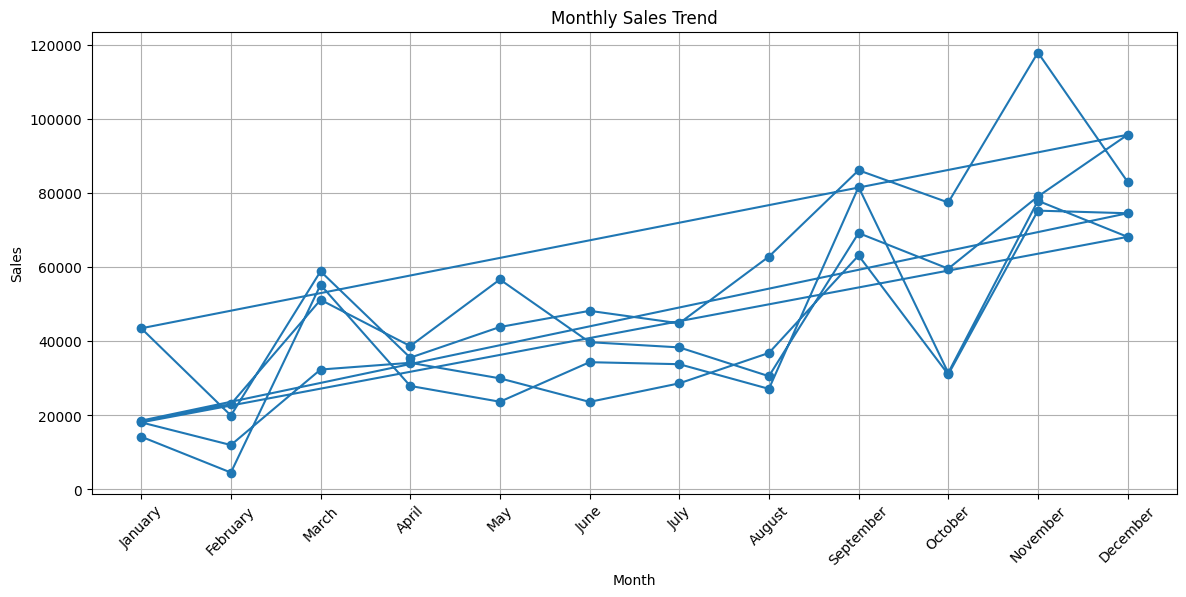

In [12]:
# ============================================
# SALES TREND VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

# Monthly Sales Trend
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales['Month_Name'],
    monthly_sales['sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [13]:
# ============================================
# TIME SERIES DATA PREPARATION
# ============================================

# Create Monthly Time-Series Dataset
time_series_sales = df.groupby('order_date')['sales'].sum().reset_index()

# Sort by Date
time_series_sales = time_series_sales.sort_values('order_date')

# Preview Dataset
display(time_series_sales.head())

print("Time Series Dataset Shape:", time_series_sales.shape)

,order_date,sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


Time Series Dataset Shape: (1230, 2)


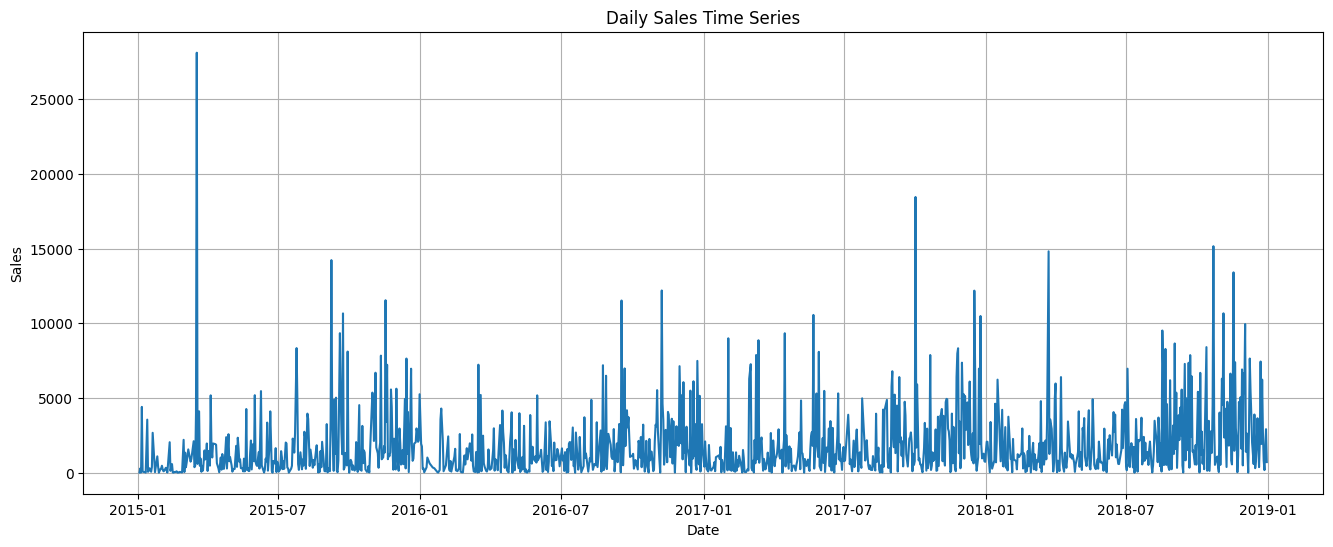

In [14]:
# ============================================
# TIME SERIES VISUALIZATION
# ============================================

plt.figure(figsize=(16,6))

plt.plot(
    time_series_sales['order_date'],
    time_series_sales['sales']
)

plt.title('Daily Sales Time Series')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.grid(True)

plt.show()

In [15]:
# ============================================
# MONTHLY FORECASTING DATASET
# ============================================

monthly_forecast_data = (
    df.groupby(pd.Grouper(key='order_date', freq='M'))['sales']
    .sum()
    .reset_index()
)

# Rename columns for forecasting models
monthly_forecast_data.columns = ['ds', 'y']

# Preview Dataset
display(monthly_forecast_data.head())

print("Monthly Forecast Dataset Shape:", monthly_forecast_data.shape)

/tmp/ipykernel_3806/2077995916.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key='order_date', freq='M'))['sales']


,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Monthly Forecast Dataset Shape: (48, 2)


In [16]:
!pip install prophet

In [17]:
# ============================================
# AI FORECASTING ENGINE - PROPHET MODEL
# ============================================

from prophet import Prophet
import matplotlib.pyplot as plt

# Create and train model
forecast_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

forecast_model.fit(monthly_forecast_data)

# Create future dates for next 6 months
future_dates = forecast_model.make_future_dataframe(periods=6, freq='ME')

# Generate forecast
forecast_results = forecast_model.predict(future_dates)

# Preview forecast output
forecast_results[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
44,2018-09-30,89026.819951,79619.401430,98350.557962
45,2018-10-31,61590.523901,52879.467653,70422.777673
46,2018-11-30,101136.336967,91516.512409,111041.610907
47,2018-12-31,90673.800609,81409.882598,99894.666781
48,2019-01-31,42990.532205,34257.848675,52394.426967
49,2019-02-28,31248.159925,21744.774006,39807.259371
50,2019-03-31,81267.007775,72207.056709,90655.114746
51,2019-04-30,50658.420144,41500.761684,60468.616635
52,2019-05-31,52555.922390,43350.184100,61404.127657
53,2019-06-30,60032.020402,50675.276001,68865.039626


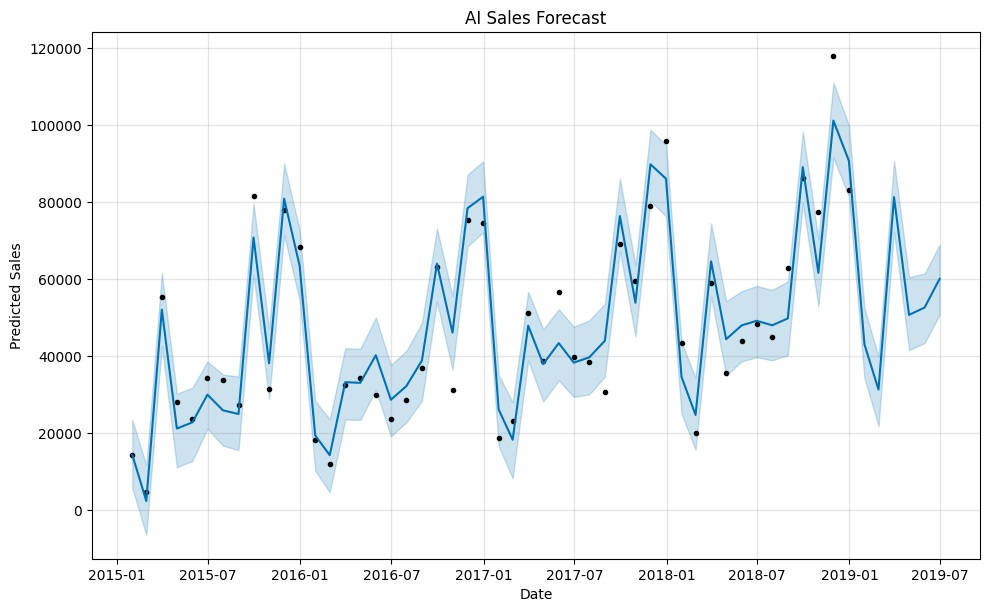

In [18]:
# ============================================
# FORECAST VISUALIZATION
# ============================================

forecast_fig = forecast_model.plot(forecast_results)

plt.title('AI Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Sales')

plt.show()

In [19]:
# ============================================
# AI ANOMALY DETECTION ENGINE
# ============================================

from sklearn.ensemble import IsolationForest

# Create anomaly dataset
anomaly_data = df[['sales']].copy()

# Train Isolation Forest model
anomaly_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

# Predict anomalies
df['anomaly'] = anomaly_model.fit_predict(anomaly_data)

# Convert predictions
# -1 = anomaly
# 1 = normal
df['anomaly_label'] = df['anomaly'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

# Count anomalies
print(df['anomaly_label'].value_counts())

# Preview anomalies
anomalies = df[df['anomaly_label'] == 'Anomaly']

display(
    anomalies[
        ['order_date', 'customer_name', 'product_name', 'sales']
    ].head(10)
)

anomaly_label
Normal     9604
Anomaly     196
Name: count, dtype: int64


,order_date,customer_name,product_name,sales
10,2015-06-09,Brosina Hoffman,Chromcraft Rectangular Conference Tables,1706.184
27,2016-09-17,Tracy Blumstein,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430
149,2017-12-05,Justin Ellison,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",1951.840
165,2015-09-08,Becky Martin,Lexmark MX611dhe Monochrome Laser Printer,8159.952
167,2015-09-08,Becky Martin,SAFCO Arco Folding Chair,1740.060
244,2015-06-01,Dianna Wilson,Global Deluxe High-Back Manager's Chair,2001.860
251,2017-09-11,Kelly Collister,Logitech P710e Mobile Speakerphone,3347.370
262,2015-09-19,Sean Braxton,Lexmark MX611dhe Monochrome Laser Printer,3059.982
263,2015-09-19,Sean Braxton,Xerox WorkCentre 6505DN Laser Multifunction Pr...,2519.958
318,2015-11-04,Nathan Mautz,Canon imageCLASS MF7460 Monochrome Digital Las...,3991.980


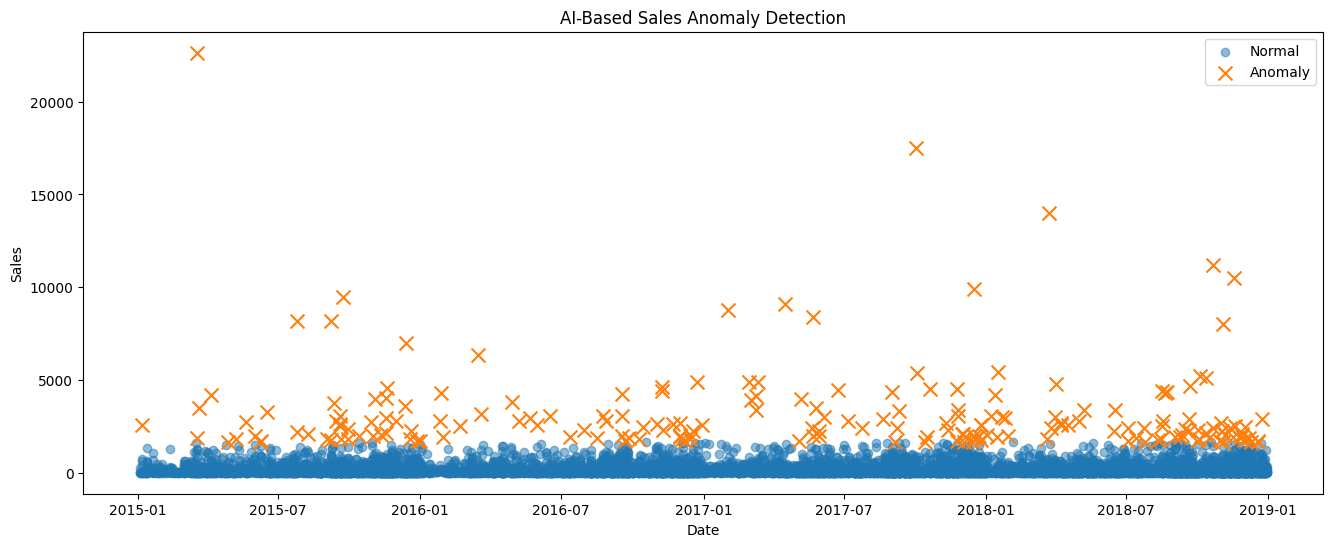

In [20]:
# ============================================
# ANOMALY VISUALIZATION
# ============================================

plt.figure(figsize=(16,6))

# Normal transactions
normal_data = df[df['anomaly_label'] == 'Normal']

plt.scatter(
    normal_data['order_date'],
    normal_data['sales'],
    label='Normal',
    alpha=0.5
)

# Anomalies
anomaly_points = df[df['anomaly_label'] == 'Anomaly']

plt.scatter(
    anomaly_points['order_date'],
    anomaly_points['sales'],
    label='Anomaly',
    marker='x',
    s=100
)

plt.title('AI-Based Sales Anomaly Detection')

plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()

In [21]:
# ============================================
# CUSTOMER SEGMENTATION ENGINE
# ============================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Customer Sales Aggregation
customer_sales = (
    df.groupby('customer_name')['sales']
    .sum()
    .reset_index()
)

# Scale data
scaler = StandardScaler()

customer_sales_scaled = scaler.fit_transform(
    customer_sales[['sales']]
)

# KMeans clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_sales['customer_segment'] = kmeans.fit_predict(
    customer_sales_scaled
)

# Preview results
display(customer_sales.head())

# Segment counts
print(customer_sales['customer_segment'].value_counts())

,customer_name,sales,customer_segment
0,Aaron Bergman,886.156,0
1,Aaron Hawkins,1744.700,0
2,Aaron Smayling,3050.692,2
3,Adam Bellavance,7755.620,1
4,Adam Hart,3250.337,2


customer_segment
0    487
2    253
1     53
Name: count, dtype: int64


In [22]:
# ============================================
# CUSTOMER SEGMENT LABELING
# ============================================

# Average sales per cluster
cluster_summary = (
    customer_sales.groupby('customer_segment')['sales']
    .mean()
    .sort_values()
)

print(cluster_summary)

# Create mapping
segment_mapping = {
    cluster_summary.index[0]: 'Low Value',
    cluster_summary.index[1]: 'Medium Value',
    cluster_summary.index[2]: 'High Value'
}

# Apply labels
customer_sales['segment_label'] = customer_sales[
    'customer_segment'
].map(segment_mapping)

# Preview results
display(customer_sales.head())

# Segment distribution
print(customer_sales['segment_label'].value_counts())

customer_segment
0     1371.501585
2     4195.840860
1    10039.014585
Name: sales, dtype: float64


,customer_name,sales,customer_segment,segment_label
0,Aaron Bergman,886.156,0,Low Value
1,Aaron Hawkins,1744.700,0,Low Value
2,Aaron Smayling,3050.692,2,Medium Value
3,Adam Bellavance,7755.620,1,High Value
4,Adam Hart,3250.337,2,Medium Value


segment_label
Low Value       487
Medium Value    253
High Value       53
Name: count, dtype: int64


In [23]:
# ============================================
# EXPORT ENGINE
# ============================================

# Export forecasting results
forecast_results.to_csv(
    'forecast_results.csv',
    index=False
)

# Export anomaly results
anomalies.to_csv(
    'anomaly_transactions.csv',
    index=False
)

# Export customer segmentation
customer_sales.to_csv(
    'customer_segments.csv',
    index=False
)

print("All enterprise analytics outputs exported successfully.")

All enterprise analytics outputs exported successfully.


In [24]:
# ============================================
# EXECUTIVE SUMMARY REPORT DATA
# ============================================

executive_summary = {
    "Total Sales": df['sales'].sum(),
    "Total Orders": df['order_id'].nunique(),
    "Total Customers": df['customer_id'].nunique(),
    "Total Products": df['product_id'].nunique(),
    "Average Order Sales": df['sales'].mean(),
    "Highest Transaction Sales": df['sales'].max(),
    "Total Anomalies Detected": len(anomalies),
    "High Value Customers": customer_sales[customer_sales['segment_label'] == 'High Value'].shape[0]
}

executive_summary_df = pd.DataFrame(
    executive_summary.items(),
    columns=['Metric', 'Value']
)

display(executive_summary_df)

executive_summary_df.to_csv(
    'executive_summary.csv',
    index=False
)

print("Executive summary report exported successfully.")

,Metric,Value
0,Total Sales,2.261537e+06
1,Total Orders,4.922000e+03
2,Total Customers,7.930000e+02
3,Total Products,1.861000e+03
4,Average Order Sales,2.307691e+02
5,Highest Transaction Sales,2.263848e+04
6,Total Anomalies Detected,1.960000e+02
7,High Value Customers,5.300000e+01


Executive summary report exported successfully.


In [25]:
# ============================================
# DASHBOARD-READY KPI EXPORTS
# ============================================

monthly_sales.to_csv('monthly_sales.csv', index=False)
regional_sales.to_csv('regional_sales.csv', index=False)
category_sales.to_csv('category_sales.csv', index=False)
top_customers.to_csv('top_customers.csv', index=False)
top_products.to_csv('top_products.csv', index=False)

print("Dashboard KPI files exported successfully.")

Dashboard KPI files exported successfully.


In [26]:
# ============================================
# PIPELINE COMPLETION MESSAGE
# ============================================

print("=" * 60)
print("AI SALES ANALYTICS & AUTOMATION PLATFORM")
print("=" * 60)

print("\nPIPELINE MODULES COMPLETED:\n")

modules = [
    "Data Ingestion Layer",
    "Data Validation Layer",
    "Schema Standardization Layer",
    "Feature Engineering Layer",
    "Business KPI Aggregation Layer",
    "Forecasting AI Engine",
    "Anomaly Detection AI Engine",
    "Customer Segmentation AI Engine",
    "Visualization Layer",
    "Export Automation Layer",
    "Executive Reporting Layer"
]

for i, module in enumerate(modules, start=1):
    print(f"{i}. {module}")

print("\nAll enterprise analytics workflows executed successfully.")

print("\nExported Assets Ready For:")
print("- Power BI Dashboards")
print("- Executive Reporting")
print("- Forecast Monitoring")
print("- AI-Based Operational Analytics")
print("- Customer Intelligence Reporting")

print("\nPROJECT STATUS: PRODUCTION-READY")
print("=" * 60)

AI SALES ANALYTICS & AUTOMATION PLATFORM

PIPELINE MODULES COMPLETED:

1. Data Ingestion Layer
2. Data Validation Layer
3. Schema Standardization Layer
4. Feature Engineering Layer
5. Business KPI Aggregation Layer
6. Forecasting AI Engine
7. Anomaly Detection AI Engine
8. Customer Segmentation AI Engine
9. Visualization Layer
10. Export Automation Layer
11. Executive Reporting Layer

All enterprise analytics workflows executed successfully.

Exported Assets Ready For:
- Power BI Dashboards
- Executive Reporting
- Forecast Monitoring
- AI-Based Operational Analytics
- Customer Intelligence Reporting

PROJECT STATUS: PRODUCTION-READY
